Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


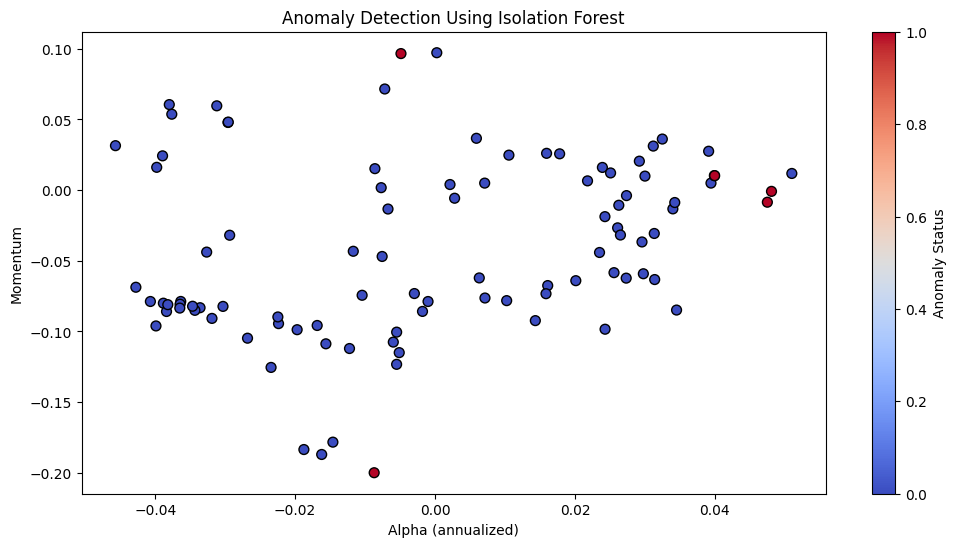

Total Records: 96
Anomalies Detected: 5


In [8]:
# Ensure dependencies are installed
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn

# Import required libraries
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore, chi2
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

# Set up file paths
drive_dir = r'/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'Regression.xlsx')
factor_output = pd.read_excel(file_path)


# Ensure 'Date' is in datetime format and sort the data
factor_output['Date'] = pd.to_datetime(factor_output['Date'])
factor_output = factor_output.sort_values(by='Date')

# Extract features for anomaly detection
features = ['Alpha..annualisiert.', 'Value.Growth', 'Small.Large', 'Momentum', 'Volatility']
feature_data = factor_output[features]

# Preprocess the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(feature_data)

# Isolation Forest
isolation_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_anomaly_scores = isolation_forest.fit_predict(scaled_data)  # -1 indicates anomalies
factor_output['IsolationForest_Anomaly'] = (iso_anomaly_scores == -1)
factor_output['IsolationForest_Score'] = isolation_forest.decision_function(scaled_data)

# Save Results
factor_output['Anomaly'] = anomalies
factor_output['AnomalyScore'] = anomaly_score_values

# Visualize Anomalies
plt.figure(figsize=(12, 6))

# Plot a scatter plot using two selected features (e.g., Alpha and Momentum)
plt.scatter(
    factor_output['Alpha..annualisiert.'],
    factor_output['Momentum'],
    c=factor_output['Anomaly'],
    cmap="coolwarm",
    edgecolor="k",
    s=50
)
plt.title("Anomaly Detection Using Isolation Forest")
plt.xlabel("Alpha (annualized)")
plt.ylabel("Momentum")
plt.colorbar(label="Anomaly Status")
plt.show()

# Summarize Anomalies
total_records = len(factor_output)
total_anomalies = sum(factor_output['Anomaly'])

print(f"Total Records: {total_records}")
print(f"Anomalies Detected: {total_anomalies}")


In [9]:
from sklearn.neighbors import LocalOutlierFactor

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_anomaly_scores = lof.fit_predict(scaled_data)  # -1 indicates anomalies
factor_output['LOF_Anomaly'] = (lof_anomaly_scores == -1)
factor_output['LOF_Score'] = -lof.negative_outlier_factor_  # Higher scores indicate higher abnormality


In [10]:
# Compare anomalies detected by both methods
factor_output['Consensus_Anomaly'] = (
    factor_output['IsolationForest_Anomaly'] & factor_output['LOF_Anomaly']
)

# Summarize anomalies
total_records = len(factor_output)
iso_anomalies = factor_output['IsolationForest_Anomaly'].sum()
lof_anomalies = factor_output['LOF_Anomaly'].sum()
consensus_anomalies = factor_output['Consensus_Anomaly'].sum()

print(f"Total Records: {total_records}")
print(f"Isolation Forest Anomalies: {iso_anomalies}")
print(f"LOF Anomalies: {lof_anomalies}")
print(f"Consensus Anomalies: {consensus_anomalies}")


Total Records: 96
Isolation Forest Anomalies: 5
LOF Anomalies: 5
Consensus Anomalies: 1


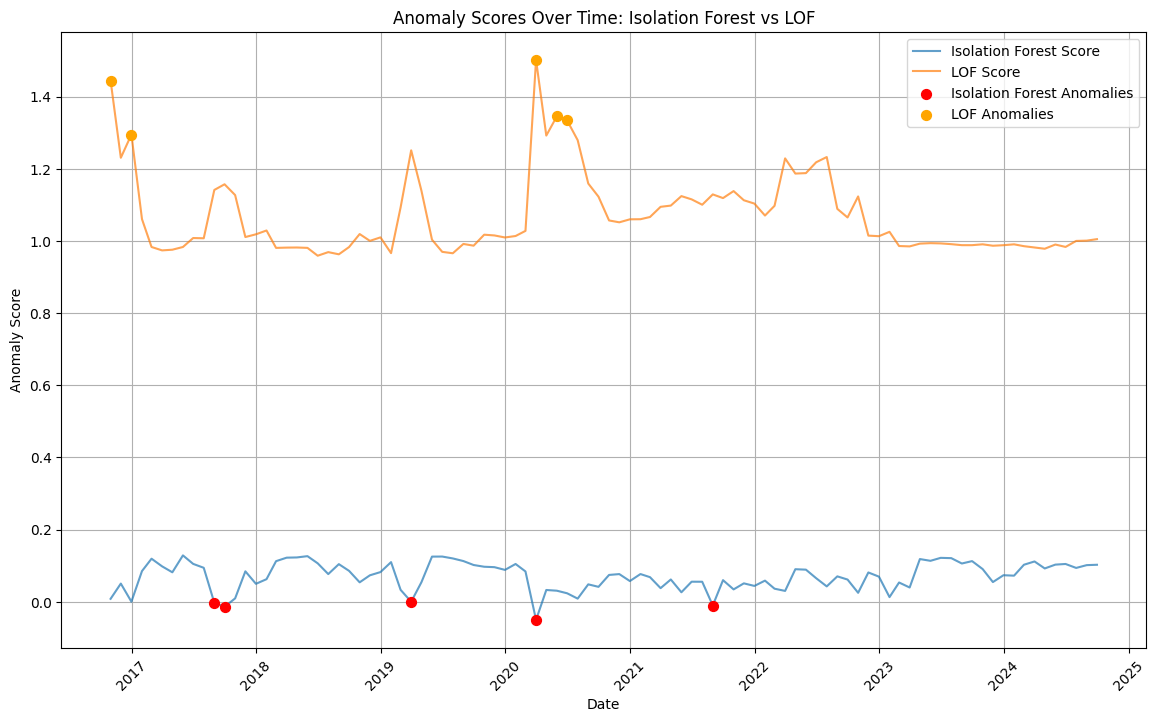

In [13]:
import matplotlib.pyplot as plt

# Line plot of anomaly scores over time for Isolation Forest and LOF
plt.figure(figsize=(14, 8))

# Plot Isolation Forest scores
plt.plot(factor_output['Date'], factor_output['IsolationForest_Score'], label="Isolation Forest Score", alpha=0.7)

# Plot LOF scores
plt.plot(factor_output['Date'], factor_output['LOF_Score'], label="LOF Score", alpha=0.7)

# Highlight anomalies detected by both methods
plt.scatter(
    factor_output['Date'][factor_output['IsolationForest_Anomaly']],
    factor_output['IsolationForest_Score'][factor_output['IsolationForest_Anomaly']],
    color='red', label="Isolation Forest Anomalies", s=50, zorder=5
)
plt.scatter(
    factor_output['Date'][factor_output['LOF_Anomaly']],
    factor_output['LOF_Score'][factor_output['LOF_Anomaly']],
    color='orange', label="LOF Anomalies", s=50, zorder=5
)

# Add labels, legend, and grid
plt.xlabel("Date")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Scores Over Time: Isolation Forest vs LOF")
plt.legend()
plt.xticks(rotation=45)
plt.grid()

plt.show()


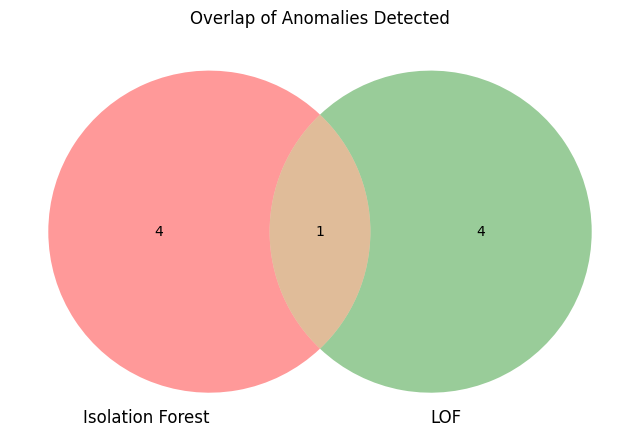

In [11]:
from matplotlib_venn import venn2

# Venn Diagram of anomaly detection overlap
iso_anomaly_set = set(factor_output.index[factor_output['IsolationForest_Anomaly']])
lof_anomaly_set = set(factor_output.index[factor_output['LOF_Anomaly']])

plt.figure(figsize=(8, 6))
venn2([iso_anomaly_set, lof_anomaly_set], ('Isolation Forest', 'LOF'))
plt.title("Overlap of Anomalies Detected")
plt.show()


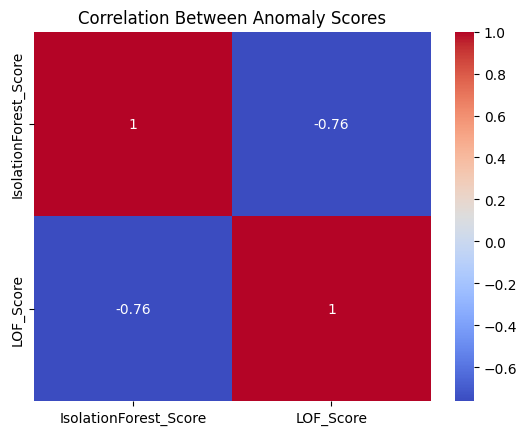

In [12]:
import seaborn as sns

# Correlation heatmap
scores_df = pd.DataFrame({
    "IsolationForest_Score": factor_output['IsolationForest_Score'],
    "LOF_Score": factor_output['LOF_Score']
})
sns.heatmap(scores_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Anomaly Scores")
plt.show()
